In [1]:
# libs
import re
import os
import pysam
import duckdb
import pandas as pd
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# RE site
pattern = re.compile('GGATG|CATCC')

# path to ref
ref_f1 = '../references/f1_data_after_indices_two_files.fasta'
ref_p2 = '../references/p2_design.fasta'
ref_c1 = '../references/data_genomika_constrained_indexed.fasta'

# list of BAM files
bams = {
    "hp_f1": "../data/BEGONIA_2/begonia_2_trim_filter_9_mapped.bam",
    "nj_f1": "../data/BEGONIA_4/begonia_4_trim_filter_9_mapped.bam",
    "hp_p2": "../data/CAMELLIA_007/camellia_007_trim_filter_9_mapped.bam",
    "nj_p2": "../data/CAMELLIA_008/camellia_008_trim_filter_9_mapped.bam",
    "hp_c1": "../data/CAMELLIA_11/camellia_11_trim_filter_9_mapped.bam",
    "nj_c1": "../data/CAMELLIA_17/camellia_17_trim_filter_9_mapped.bam",
}

In [3]:
# function to identify references with RS stit matches
def find_reference_matches(ref, pattern):
    reference_matches = {}
    with pysam.FastaFile(ref) as fasta:
        for reference in fasta.references:
            sequence = fasta.fetch(reference)
            # find all matches of RS in the ref
            matches = [(m.start(), m.end()) for m in pattern.finditer(sequence)]
            if matches:
                reference_matches[reference] = matches
    return reference_matches

# function to process a BAM file
def extract_and_annotate_reads_bam_chunked(
    bam_dict,
    reference_matches,
    out_prefix,
    ref_len=140,
    rs_thresh=5,
    trunc_lfrac=0.95,
    chunk_size=10000000,
):
    file_counter = 0

    def is_rs_site(row):
        rs_sites = reference_matches.get(row['ref_id'], [])
        for rs_start, rs_end in rs_sites:
            in_window = (
                ((row['start'] <= rs_end + rs_thresh) and (row['end'] >= rs_start - rs_thresh)) and
                not ((row['start'] <= rs_end) and (row['end'] >= rs_start))
            )
            flanking_left = (row['end'] < rs_start) and ((rs_start - row['end']) <= rs_thresh)
            flanking_right = (rs_end < row['start']) and ((row['start'] - rs_end) <= rs_thresh)
            if in_window or flanking_left or flanking_right:
                return True
        return False

    for name, bam_file in bam_dict.items():
        with pysam.AlignmentFile(bam_file, "rb") as bam:
            chunk = []
            for read in bam:
                if read.is_mapped and not read.is_secondary and not read.is_supplementary:
                    reference_name = bam.get_reference_name(read.reference_id)
                    row = {
                        "read_id": read.query_name,
                        "name": name,
                        "ref_id": reference_name,
                        "start": read.reference_start,
                        "end": read.reference_end,
                        "NM": read.get_tag("NM") if read.has_tag("NM") else None,
                    }
                    chunk.append(row)
                if len(chunk) >= chunk_size:
                    df = pd.DataFrame(chunk)
                    if not df.empty:
                        df['prot'] = df['name'].str.split('_').str[0]
                        df['pool'] = df['name'].str.split('_').str[1]
                        df['width'] = df['end'] - df['start']
                        df['lfrac'] = df['width'] / ref_len
                        df['is_truncated'] = df['lfrac'] < trunc_lfrac
                        df['rs_site'] = df.apply(is_rs_site, axis=1)
                        df['is_rs'] = df['ref_id'].map(lambda ref: bool(reference_matches.get(ref, [])))
                        df.to_parquet(
                            f"{out_prefix}.part{file_counter:04d}.parquet", index=False)
                        file_counter += 1
                    chunk = []
            if chunk:
                df = pd.DataFrame(chunk)
                if not df.empty:
                    df['prot'] = df['name'].str.split('_').str[0]
                    df['pool'] = df['name'].str.split('_').str[1]
                    df['width'] = df['end'] - df['start']
                    df['lfrac'] = df['width'] / ref_len
                    df['is_truncated'] = df['lfrac'] < trunc_lfrac
                    df['rs_site'] = df.apply(is_rs_site, axis=1)
                    df['is_rs'] = df['ref_id'].map(lambda ref: bool(reference_matches.get(ref, [])))
                    df.to_parquet(
                        f"{out_prefix}.part{file_counter:04d}.parquet", index=False)
                    file_counter += 1

    if file_counter == 0:
        cols = [
            "read_id", "name", "ref_id", "start", "end", "NM",
            "width", "lfrac", "is_truncated", "rs_site", "is_rs", "prot", "pool"
        ]
        pd.DataFrame(columns=cols).to_parquet(f"{out_prefix}.part0000.parquet", index=False)


In [4]:
# get references matching the RS
f1_matches = find_reference_matches(
    ref_f1, pattern
)
p2_matches = find_reference_matches(
    ref_p2, pattern
)
c1_matches = find_reference_matches(
    ref_c1, pattern
)
# mock match
c1_matches = {'0001': [(5, 10)]}

print("F1:", len(f1_matches))
print("P2:", len(p2_matches))
print("C1:", len(c1_matches))

F1: 31301
P2: 282
C1: 1


In [5]:
# total sequences
f1_fasta = pysam.FastaFile(ref_f1)
print("F1:", len(f1_fasta.references))
f1_fasta.close()

p2_fasta = pysam.FastaFile(ref_p2)
print("P2:", len(p2_fasta.references))
p2_fasta.close()

c1_fasta = pysam.FastaFile(ref_c1)
print("C1:", len(c1_fasta.references))
c1_fasta.close()

F1: 110000
P2: 1000
C1: 1644


In [6]:
# get rs matches to df
extract_and_annotate_reads_bam_chunked(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)},
    f1_matches, out_prefix = "../results/re_stats_f1"
)
extract_and_annotate_reads_bam_chunked(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    p2_matches, out_prefix = "../results/re_stats_p2"
)
extract_and_annotate_reads_bam_chunked(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    c1_matches, out_prefix = "../results/re_stats_c1"
)

In [7]:
query = """
SELECT prot, pool, COUNT(*) AS n_reads, 
    SUM(CASE WHEN rs_site AND is_truncated THEN 1 ELSE 0 END) AS n_trunc_at_rs
FROM (
    SELECT * FROM '../results/re_stats_f1.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_p2.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_c1.part*.parquet'
)
GROUP BY prot, pool
"""

res_all = duckdb.query(query).fetchdf()
res_all

,prot,pool,n_reads,n_trunc_at_rs
0,hp,f1,27658529,66836.0
1,nj,f1,48677577,2582943.0
2,hp,c1,865263,8.0
3,nj,c1,910722,8.0
4,hp,p2,77964776,121687.0
5,nj,p2,41889863,3826296.0


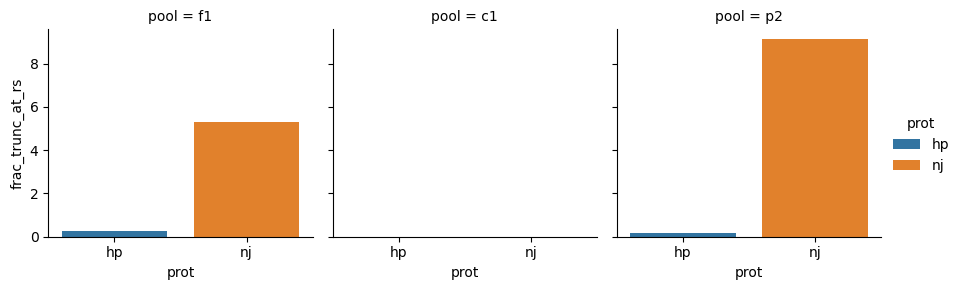

In [8]:
res_all['frac_trunc_at_rs'] = res_all['n_trunc_at_rs']/res_all['n_reads']*100

p1 = sns.FacetGrid(
    res_all,
    col='pool',
    hue='prot',
    sharex=False,
    sharey=True
)
p1.map_dataframe(sns.barplot, x='prot', y='frac_trunc_at_rs', order=res_all['prot'].unique())
p1.add_legend()

In [9]:
#res_all.to_csv(
#    f"../results/res_rs_trunc_frac_total.csv", index=False
#)

In [10]:
query = """
SELECT 
    prot,
    pool,
    SUM(CASE WHEN is_truncated AND rs_site THEN 1 ELSE 0 END)::DOUBLE /
        NULLIF(SUM(CASE WHEN is_rs THEN 1 ELSE 0 END), 0) AS fraction_re_trunc
FROM (
    SELECT * FROM '../results/re_stats_f1.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_p2.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_c1.part*.parquet'
)
GROUP BY prot, pool
"""

res_rs = duckdb.query(query).fetchdf()

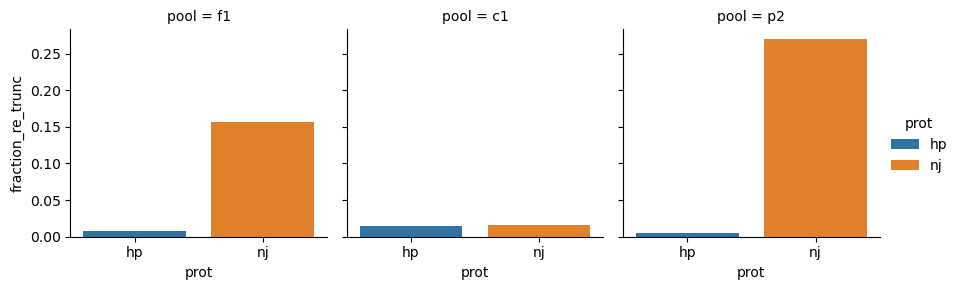

In [11]:
p2 = sns.FacetGrid(
    res_rs,
    col='pool',
    hue='prot',
    sharex=False,
    sharey=True
)
p2.map_dataframe(sns.barplot, x='prot', y='fraction_re_trunc', order=res_rs['prot'].unique())
p2.add_legend()

In [12]:
#res_rs.to_csv(
#    f"../results/res_rs_trunc_frac_rrs.csv", index=False
#)

In [13]:
query = """
SELECT prot, pool, name, lfrac
FROM (
    SELECT * FROM '../results/re_stats_f1.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_p2.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_c1.part*.parquet'
)
"""

lfrac_df = duckdb.query(query).fetchdf()

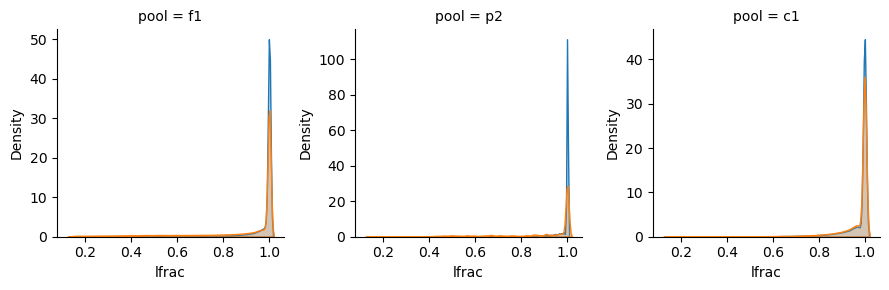

In [14]:
p3 = sns.FacetGrid(
    lfrac_df,
    col="pool",
    hue="prot",
    sharex=False, sharey=False
)
p3.map(sns.kdeplot, "lfrac", fill=True)
plt.show()

In [15]:
query = """
SELECT prot, pool, name, lfrac
FROM (
    SELECT * FROM '../results/re_stats_f1.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_p2.part*.parquet'
    UNION ALL
    SELECT * FROM '../results/re_stats_c1.part*.parquet'
)
WHERE is_rs = TRUE
"""

lfrac_rs_df = duckdb.query(query).fetchdf()

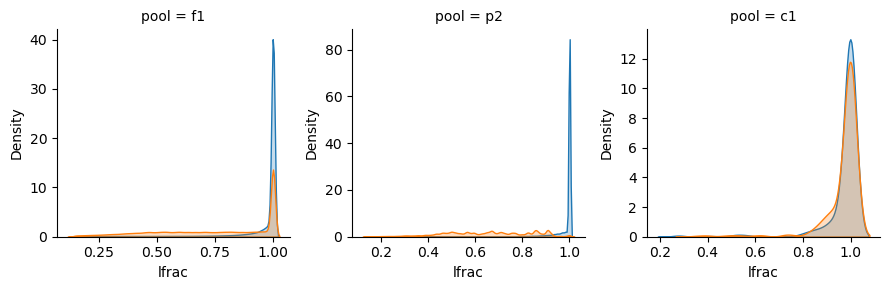

In [16]:
p4 = sns.FacetGrid(
    lfrac_rs_df,
    col="pool",
    hue="prot",
    sharex=False, sharey=False
)
p4.map(sns.kdeplot, "lfrac", fill=True)
plt.show()

In [17]:
# extract chimeric reads
def chimeric_reads_bam(
    bam_dict,
    reference_matches,
    tolerance=0,
    out=None
):

    def overlaps_in_read(a, b):
        return (
            a["alignment_start_in_read"] < b["alignment_end_in_read"] + tolerance
            and
            a["alignment_end_in_read"] + tolerance > b["alignment_start_in_read"]
        )

    paired_rows = []

    for name, bam_file in bam_dict.items():
        with pysam.AlignmentFile(bam_file, "rb") as bam:  # <- use context manager
            read_alignments = {}

            for read in bam:
                read_id = read.query_name
                if read.is_unmapped:
                    continue

                ref_id = bam.get_reference_name(read.reference_id)
                if ref_id is None:
                    continue

                nm = read.get_tag("NM") if read.has_tag("NM") else None
                if nm is None or nm > 4:
                    continue  # keep NM filter for chimera detection

                is_primary = not (read.is_secondary or read.is_supplementary)
                is_supplementary = read.is_supplementary
                direction = "-" if read.is_reverse else "+"

                astart = read.query_alignment_start
                aend = read.query_alignment_end

                is_regex = ref_id in reference_matches
                regex_pos = ",".join(f"{st}-{en}" for st, en in reference_matches.get(ref_id, [])) if is_regex else None

                rec = {
                    "bam_name": name,
                    "read_id": read_id,
                    "ref_id": ref_id,
                    "start": read.reference_start,
                    "end": read.reference_end,
                    "read_length": read.query_length,
                    "nm": nm,
                    "direction": direction,
                    "is_primary": is_primary,
                    "is_supplementary": is_supplementary,
                    "is_regex": is_regex,
                    "regex_pos": regex_pos,
                    "alignment_start_in_read": astart,
                    "alignment_end_in_read": aend,
                }

                read_alignments.setdefault(read_id, []).append(rec)

        # find chimeric pairs
        for read_id, aligns in read_alignments.items():
            primary_aligns = [a for a in aligns if a["is_primary"]]
            non_primary_aligns = [a for a in aligns if not a["is_primary"]]

            if not primary_aligns or not non_primary_aligns:
                continue

            for i, pa in enumerate(primary_aligns, start=1):
                for j, sa in enumerate(non_primary_aligns, start=1):
                    if not overlaps_in_read(pa, sa):
                        pair_id = f"{name}:{read_id}_p{i}_s{j}"

                        row = {
                            "pair_id": pair_id,
                            "p_ref_id": pa["ref_id"],
                            "p_start": pa["start"],
                            "p_end": pa["end"],
                            "p_nm": pa["nm"],
                            "p_direction": pa["direction"],
                            "p_alignment_start_in_read": pa["alignment_start_in_read"],
                            "p_alignment_end_in_read": pa["alignment_end_in_read"],
                            "s_ref_id": sa["ref_id"],
                            "s_start": sa["start"],
                            "s_end": sa["end"],
                            "s_nm": sa["nm"],
                            "s_direction": sa["direction"],
                            "s_alignment_start_in_read": sa["alignment_start_in_read"],
                            "s_alignment_end_in_read": sa["alignment_end_in_read"],
                            "read_id": read_id,
                            "bam_name": pa["bam_name"],
                            "read_length": pa["read_length"],
                            "is_regex_primary": pa["is_regex"],
                            "regex_pos_primary": pa["regex_pos"],
                            "is_regex_secondary": sa["is_regex"],
                            "regex_pos_secondary": sa["regex_pos"],
                            "is_supplementary_secondary": sa["is_supplementary"],
                        }

                        paired_rows.append(row)

    df = pd.DataFrame(paired_rows)

    # save to parquet
    if out and not df.empty:
        df.to_parquet(out, index=False)

    #return df


In [18]:
# get chimeras
chimeric_reads_bam(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)},
    f1_matches, tolerance=5,
    out = "../results/chimeric_reads_f1.parquet"
)
chimeric_reads_bam(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    p2_matches, tolerance=5,
    out = "../results/chimeric_reads_p2.parquet"
)

In [19]:
query = """
    SELECT * FROM '../results/chimeric_reads_*.parquet'
"""

res_ch = duckdb.query(query).fetchdf()

In [20]:
tol = 5
min_len = 60
nm_max = 4

def explode_and_flag(df, prefix, regex_col, tol, min_len):
    return (
        df
        .assign(**{regex_col: df[regex_col].str.split(',')})
        .explode(regex_col)
        .dropna(subset=[regex_col])
        .loc[lambda d: (d[f'{prefix}_end'] - d[f'{prefix}_start']) >= min_len]
        .assign(**{
            f'{prefix}_regex_start': lambda d: d[regex_col].str.strip().str.split('-', expand=True)[0].astype(int),
            f'{prefix}_regex_end':   lambda d: d[regex_col].str.strip().str.split('-', expand=True)[1].astype(int),
        })
        .assign(**{
            f'{prefix}_close': lambda d: (
                (d[f'{prefix}_end']   - d[f'{prefix}_regex_start']).abs() <= tol
            ) | (
                (d[f'{prefix}_start'] - d[f'{prefix}_regex_end']).abs()   <= tol
            )
        })
        .groupby(['bam_name','pair_id'])[f'{prefix}_close'].any()
        .reset_index()
    )

len_ok = (
    ((res_ch['p_end'] - res_ch['p_start']) >= min_len) |
    ((res_ch['s_end'] - res_ch['s_start']) >= min_len)
)
nm_ok = (
    res_ch['p_nm'].notna() & (res_ch['p_nm'] <= nm_max) &
    res_ch['s_nm'].notna() & (res_ch['s_nm'] <= nm_max)
)
res_ch_filtered = res_ch.loc[len_ok & nm_ok]

primary_summary   = explode_and_flag(res_ch_filtered, 'p', 'regex_pos_primary',   tol, min_len)
secondary_summary = explode_and_flag(res_ch_filtered, 's', 'regex_pos_secondary', tol, min_len)

df_combined = (
    res_ch_filtered
      .merge(primary_summary,   on=['bam_name','pair_id'], how='left')
      .merge(secondary_summary, on=['bam_name','pair_id'], how='left')
      .assign(
          p_close=lambda d: d['p_close'].eq(True),
          s_close=lambda d: d['s_close'].eq(True),
          close_to_rs=lambda d: d['p_close'] | d['s_close'],
          is_junction=lambda d: d['p_close'] & d['s_close']
      )
)

res_jc = (
    df_combined
      .groupby(['bam_name', 'read_id'])['is_junction'].any()
      .reset_index()
      .groupby('bam_name')
      .agg(
          total_reads=('is_junction', 'size'),
          junction_reads=('is_junction', 'sum')
      )
      .assign(junction_rate=lambda d: d['junction_reads'] / d['total_reads'] * 100)
      .reset_index()
)

res_ch_rs = (
    df_combined
      .groupby(['bam_name', 'read_id'])['close_to_rs'].any()
      .reset_index()
      .groupby(['bam_name', 'close_to_rs'])
      .size()
      .reset_index(name='count')
)


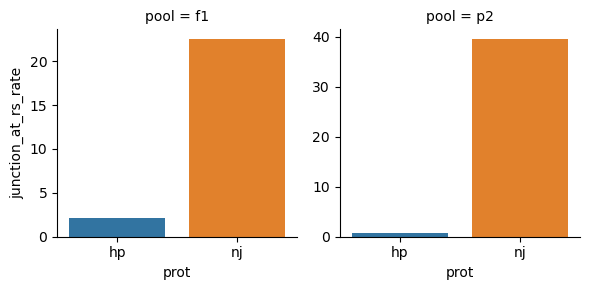

In [22]:
res_ch_rs_frac = (
    res_ch_rs
    .pivot_table(index="bam_name", columns="close_to_rs", values="count", fill_value=0)
    .rename(columns={True: "near", False: "far"})
    .assign(junction_at_rs_rate=lambda d: d["near"] / (d["near"] + d["far"]) * 100)
    .reset_index()
    .assign(
        prot=lambda d: d['bam_name'].str.split('_').str[0],
        pool=lambda d: d['bam_name'].str.split('_').str[1],
    )
)


p5=sns.FacetGrid(
    res_ch_rs_frac,
    col='pool',
    hue='prot',
    sharex=False,
    sharey=False
)
p5.map(
    sns.barplot,
    'prot',
    'junction_at_rs_rate',
    order=res_ch_rs_frac['prot'].unique()
)
plt.show()

In [ ]:
#res_ch_rs_frac.to_csv(
#    f"../results/res_ch_rs_frac.csv", index=False
#)

In [23]:
# count mapped reads
def count_primary_alignments_bam(bam_dict, fasta_file, pattern, out=None):
    # get all ref ids
    with pysam.FastaFile(fasta_file) as fasta:
        refs = list(fasta.references)
        ref_ids = pd.DataFrame({"ref_id": refs})
        # compute once per ref
        seq_by_ref = {r: fasta.fetch(r) for r in refs}
        ref_ids["is_regex"] = ref_ids["ref_id"].apply(lambda r: bool(pattern.search(seq_by_ref[r])))
        ref_ids["regex_positions"] = ref_ids["ref_id"].apply(
            lambda r: ",".join(f"{m.start()}-{m.end()}" for m in pattern.finditer(seq_by_ref[r]))
                      if ref_ids.loc[ref_ids["ref_id"] == r, "is_regex"].iat[0] else None
        )

    data = []

    # iterate over bams
    for name, bam_file in bam_dict.items():
        with pysam.AlignmentFile(bam_file, "rb") as bam:
            for read in bam:
                # primary only
                if read.is_mapped and not (read.is_secondary or read.is_supplementary):
                    ref_id = bam.get_reference_name(read.reference_id)
                    if ref_id is None:
                        continue
                    width = read.reference_end - read.reference_start
                    nm = read.get_tag("NM") if read.has_tag("NM") else None
                    data.append((name, ref_id, width, nm))

    df = pd.DataFrame(data, columns=["name", "ref_id", "width", "nm"])

    grouped_df = (
        df.groupby(["name", "ref_id", "width", "nm"])
          .size()
          .reset_index(name="count")
    )

    names = pd.DataFrame({"name": list(bam_dict.keys())})
    ref_cartesian = pd.merge(names, ref_ids, how="cross")

    res = pd.merge(ref_cartesian, grouped_df, on=["name", "ref_id"], how="left")
    res["count"] = res["count"].fillna(0).astype(int)

    if out and not res.empty:
        res.to_parquet(out, index=False)
    # return res


In [24]:
# get aligments
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)}, 
    ref_f1, pattern,
    out = "../results/aligned_reads_f1.parquet"
)
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    ref_p2, pattern,
    out = "../results/aligned_reads_p2.parquet"
)
count_primary_alignments_bam(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    ref_c1, pattern,
    out = "../results/aligned_reads_c1.parquet"
)

In [25]:
# write to csv
#res_al.to_csv(
#    "../results/f1_primary_aligment_summary.csv.gz",
#    index=False, compression="gzip"
#)

query = """
    SELECT * FROM read_parquet(
        '../results/aligned_reads_*.parquet',
        union_by_name=True
    )
"""
res_al = duckdb.query(query).fetchdf()

In [46]:
res_al_hc = (
    res_al
    .rename(columns={'is_regex': 'is_re_rs'})
    .loc[lambda df: ((df['nm'] < 4) & (df['width'] > 136)) | (df['count'] == 0)]
    .groupby(['name', 'ref_id'], as_index=False)
    .agg(n_mapped=('count', 'sum'), is_re_rs=('is_re_rs', 'first'))
    .assign(
        prot=lambda d: d['name'].str.split('_').str[0],
        pool=lambda d: d['name'].str.split('_').str[1],
        n_mapped_log1p=lambda d: np.log1p(d["n_mapped"])
    )
)

In [27]:
#res_al_hc.to_csv(
#    f"../results/res_al_hc.csv", index=False
#)

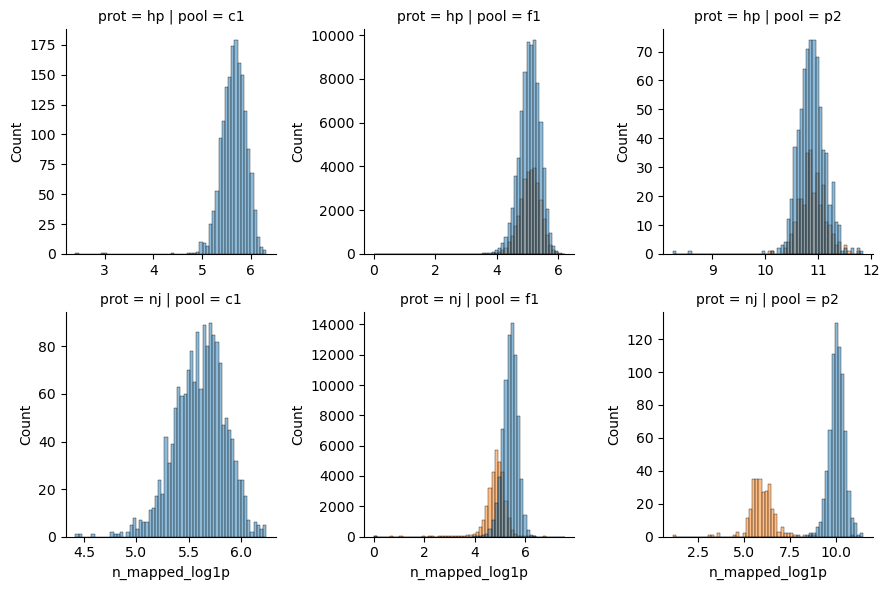

In [47]:
p6 = sns.FacetGrid(
    res_al_hc, row="prot", col="pool", sharex=False, sharey=False
)
p6.map_dataframe(
    sns.histplot,
    x="n_mapped_log1p",
    hue="is_re_rs",
    multiple="layer",
    bins = 60,
    alpha=0.5
)
plt.show()

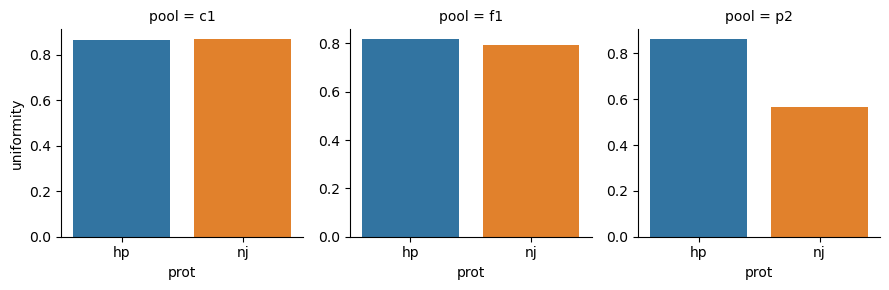

In [43]:
def gini(arr):
    arr = np.array(sorted(arr))    
    n = len(arr)
    coef_ = 2. / n
    const_ = (n + 1.) / n
    weighted_sum = sum([(i + 1) * yi for i, yi in enumerate(arr)])
    return coef_ * weighted_sum / (arr.sum()) - const_

# calculate Gini coeff
gini_coef = (
    res_al_hc
    .groupby(['prot', 'pool'])['n_mapped']
    .apply(lambda x: gini(x.values))
    .reset_index()
    .rename(columns={'n_mapped': 'gini_coef'})
    .assign(
        uniformity=lambda df: 1 - df['gini_coef']
    )
)

p7=sns.FacetGrid(
    gini_coef,
    col='pool',
    hue='prot',
    sharex=False,
    sharey=False
)

p7.map_dataframe(
    sns.barplot,
    x='prot',
    y='uniformity',
    order=gini_coef['prot'].unique()
)
plt.show()

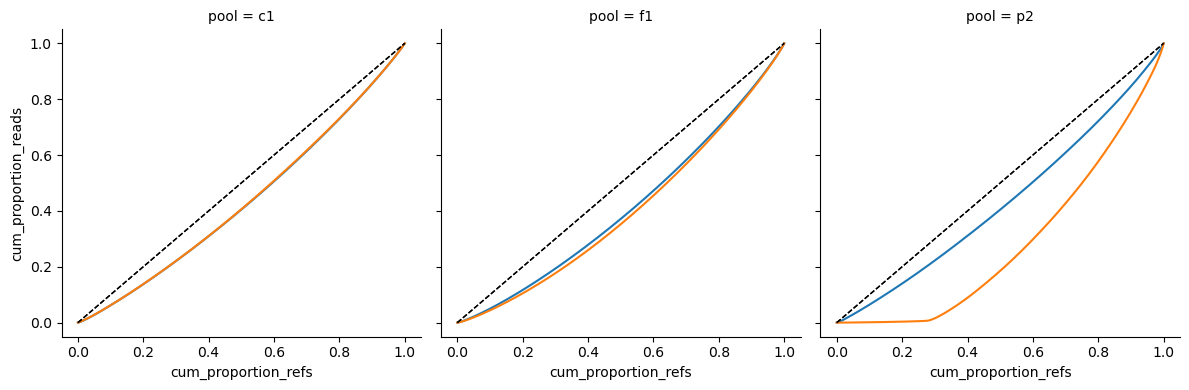

In [44]:
def lorenz_curve(arr):
    arr = np.array(sorted(arr))
    n = len(arr)
    
    if n == 0 or arr.sum() == 0:
        return np.array([0, 1]), np.array([0, 1])
        
    cum_ref = np.arange(1, n + 1) / n
    cum_val = np.cumsum(arr) / arr.sum()
    
    cum_ref = np.insert(cum_ref, 0, 0)
    cum_val = np.insert(cum_val, 0, 0)
    
    return cum_ref, cum_val

lorenz_data = []
for (prot, pool), group_df in res_al_hc.groupby(["prot", "pool"]):
    data = group_df["n_mapped"].values
    
    cum_ref, cum_val = lorenz_curve(data)
    
    # append data points
    for i in range(len(cum_ref)):
        lorenz_data.append({
            "prot": prot,
            "pool": pool,
            "cum_proportion_refs": cum_ref[i],
            "cum_proportion_reads": cum_val[i]
        })

lorenz_df = pd.DataFrame(lorenz_data)

p8=sns.FacetGrid(
    data=lorenz_df, 
    col="pool", 
    hue="prot",
    height=4,
    aspect=1
)

p8.map_dataframe(
    sns.lineplot, 
    x="cum_proportion_refs", 
    y="cum_proportion_reads"
)

def plot_diagonal(*args, **kwargs):
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

p8.map(plot_diagonal)
plt.show()